In [3]:
from collections import deque
graph = {
    'A':['B','C'],
    'B':['D','E'],
    'C':['F'],
    'D':[],
    'E':[],
    'F':[]
}
# BFS
def bfs(graph,start):
  visited = set()
  queue = deque([start])

  while queue:
    node=queue.popleft()
    if node not in visited:
      print(node, end=" ")
      visited.add(node)
      queue.extend(graph[node])


# DFS
def dfs(graph,node,visited):
  if node not in visited:
    print(node, end=" ")
    visited.add(node)
    for neighbour in graph[node]:
      dfs(graph,neighbour,visited)


print("BFS:")
bfs(graph, 'A')

print("\nDFS:")
dfs(graph,'A',set())


BFS:
A B C D E F 
DFS:
A B D E C F 


Execution Time Table:
      Size  BFS Time  DFS Time
0     1000  0.000026  0.000008
1    40000  0.000794  0.000009
2    80000  0.001969  0.000013
3   200000  0.004593  0.000009
4  1000000  0.022012  0.000009


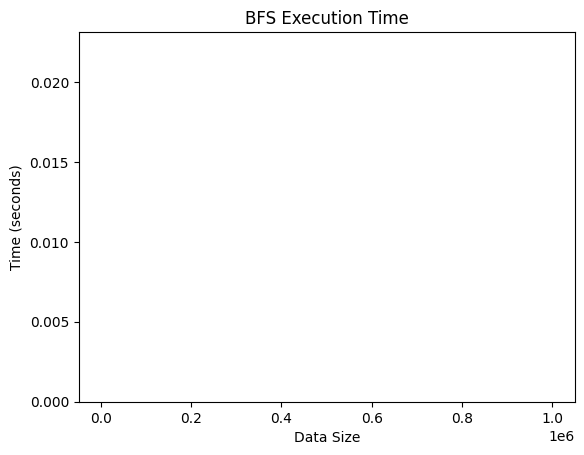

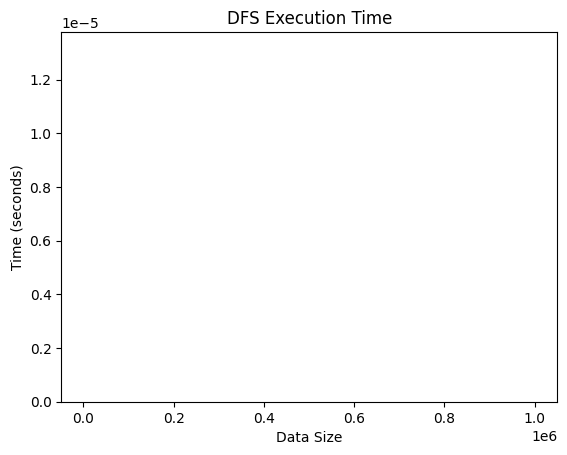

In [4]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt

sizes = [1000,40000,80000,200000,1000000]
datasets={}
for size in sizes:
  datasets[size]=random.sample(range(size*10), size)

def bfs(data, target):
  for item in data:
    if item==target:
      return True

def dfs(data,target):
  for item in reversed(data):
    if item==target:
      return True


results=[]
for size, data in datasets.items():
  target=data[len(data)-220]

  #bfs
  start=time.time()
  bfs(data, target)
  bfs_time=time.time()-start

  #dfs
  start=time.time()
  dfs(data,target)
  dfs_time=time.time()-start

  results.append([size, bfs_time, dfs_time])

# Step 5: Create DataFrame
df = pd.DataFrame(results, columns=["Size", "BFS Time", "DFS Time"])

print("\nExecution Time Table:")
print(df)

# Step 6: Plot Bar Chart

# BFS Chart
plt.figure()
plt.bar(df["Size"], df["BFS Time"])
plt.xlabel("Data Size")
plt.ylabel("Time (seconds)")
plt.title("BFS Execution Time")
plt.show()

# DFS Chart
plt.figure()
plt.bar(df["Size"], df["DFS Time"])
plt.xlabel("Data Size")
plt.ylabel("Time (seconds)")
plt.title("DFS Execution Time")
plt.show()

In [6]:
from collections import deque

graph = {
    "Islamabad": ["Rawalpindi", "Lahore", "Peshawar"],
    "Rawalpindi": ["Islamabad", "Peshawar", "Quetta"],
    "Peshawar": ["Islamabad", "Rawalpindi", "Quetta"],
    "Lahore": ["Islamabad", "Multan", "Quetta"],
    "Multan": ["Lahore", "Karachi", "Quetta"],
    "Quetta": ["Rawalpindi", "Peshawar", "Multan", "Karachi"],
    "Karachi": []
}

def shortest_path(graph, start, goal):
    queue = deque([[start]])
    visited = set()

    while queue:
        path = queue.popleft()
        node = path[-1]

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)
            for neighbor in graph[node]:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)

print(shortest_path(graph, "Islamabad", "Karachi"))



['Islamabad', 'Rawalpindi', 'Quetta', 'Karachi']
